<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_INTERMEDIO/1_JOINS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [ ]:
#Nueva base de datos
!pip install jupysql --quiet

In [ ]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [ ]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

Connecting to 'sqlite:///ferreteria.db'

<center>
<font size = '6' color =black><u><b>Consultas de varias tablas con JOINs<b/></u></font>
</center>

Hasta ahora, hemos estado trabajando con una sola tabla, pero los datos de las entidades en el mundo real a menudo se dividen en partes y se almacenan en múltiples tablas ortogonales utilizando un proceso conocido como normalización.

<u><b>Normalización de la base de datos:</b></u>

La normalización de bases de datos es útil porque minimiza la duplicación de datos en cualquier tabla y permite que los datos crezcan de forma independiente (por ejemplo, los tipos de motores de automóviles pueden crecer independientemente de cada tipo de automóvil). Como contrapartida, las consultas se vuelven un poco más complejas, ya que deben poder encontrar datos en diferentes partes de la base de datos, y pueden surgir problemas de rendimiento al trabajar con muchas tablas grandes.

Para poder responder preguntas sobre una entidad que tiene datos distribuidos en varias tablas de una base de datos normalizada, necesitamos aprender a escribir una consulta que pueda combinar todos esos datos y extraer exactamente la información que necesitamos.

<u><b>En bases de datos reales casi siempre hay múltiples tablas relacionadas:</u></b>

* Una tabla de productos.
* Una tabla de clientes.
* Una tabla de ventas que se relaciona con clientes y con productos.

**Para consultar información de varias tablas al mismo tiempo, usamos los JOINs.**

**Los principales son:**

* INNER JOIN /JOIN(solo) → devuelve solo las filas que coinciden en ambas tablas.

* LEFT JOIN → devuelve todas las filas de la tabla izquierda y las coincidentes de la derecha (o NULL si no hay coincidencia).

* RIGHT JOIN → igual que LEFT JOIN, pero al revés.

Empezaremos con INNER JOIN que muchas veces la encontramos como JOIN:

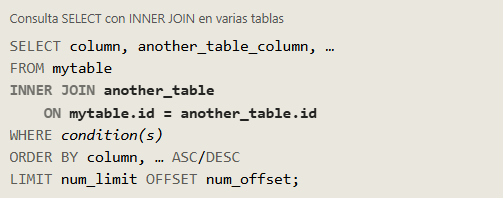

<center>
<font size = '5' color =black><u><b>EJERCICIOS INNER JOIN<b/></u></font>
</center>

Queremos saber los nombres de los clientes y en que sucursal compraron:

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

In [ ]:
%%sql
SELECT c.nombre_cliente, v.sucursal
FROM clientes c
JOIN ventas v ON c.id_cliente = v.id_cliente
LIMIT 10;

nombre_cliente,sucursal
Benjamin Perez Diaz,Sucursal Palermo
Benjamin Perez Diaz,Sucursal Palermo
Amparo Paez Rodriguez,Sucursal Mendoza
Martina Diaz Gimenez,Sucursal Córdoba
Sr(a). Thiago Agustin Quiroga,Sucursal Córdoba
Sr(a). Thiago Agustin Quiroga,Sucursal Córdoba
Sr(a). Thiago Agustin Quiroga,Sucursal Córdoba
Tomàs Victoria Aguero,Sucursal Palermo
Genaro Alma Fernandez,Sucursal Córdoba
Santino Olivia Sosa Romero,Sucursal Palermo


2. Ahora necesitamos saber el nombre del cliente y el producto que compro junto a su precio unitario

In [ ]:
%%sql
SELECT c.nombre_cliente, p.producto, p.precio_unitario
FROM clientes AS c
JOIN ventas AS v
  ON c.id_cliente = v.id_cliente
JOIN productos AS p            --seria igual a JOIN productos AS p ON v.producto = p.producto una oracion entera
  ON v.producto = p.producto
LIMIT 10;

nombre_cliente,producto,precio_unitario
Benjamin Perez Diaz,Caja de tornillos,None
Benjamin Perez Diaz,Caja de tornillos,1004.52
Benjamin Perez Diaz,Caja de tornillos,1454.09
Benjamin Perez Diaz,Caja de tornillos,1789.79
Benjamin Perez Diaz,Caja de tornillos,1855.8
Benjamin Perez Diaz,Caja de tornillos,1962.75
Benjamin Perez Diaz,Caja de tornillos,2135.64
Benjamin Perez Diaz,Caja de tornillos,2187.97
Benjamin Perez Diaz,Caja de tornillos,2634.86
Benjamin Perez Diaz,Caja de tornillos,3013.9


3-Queremos saber el cliente que compro la mayor cantidad de productos

In [ ]:
%%sql
SELECT c.nombre_cliente, v.cantidad
FROM clientes AS c
JOIN ventas AS v
  ON c.id_cliente = v.id_cliente
ORDER BY v.cantidad DESC
LIMIT 1;

nombre_cliente,cantidad
Martina Diaz Gimenez,5.0


<center>
<font size = '5' color =black><u><b>PORQUE NO USAR JOIN<b/></u></font>
</center>

La razón por la que no podemos usar simplemente JOIN (que es lo mismo que un INNER JOIN) para todo es que el JOIN normal es muy agresivo: si no encuentra una coincidencia exacta, borra la fila por completo.

Si usaras solo JOIN en la vida real, tus reportes perderían datos valiosísimos sin que te des cuenta.

<u><b>3 razones críticas de por qué no puedes usar simplemente JOIN:</u></b>

###1. Perderías dinero (Clientes sin compras)

Imagina que el departamento de Marketing te pide una lista de todos los clientes registrados para mandarles un correo.

* Si usas JOIN, la base de datos solo te devolverá los clientes que sí han comprado.

* El problema: ¡Vas a dejar fuera a todos los clientes nuevos que se registraron pero aún no compran! Perderías la oportunidad de mandarles un cupón de descuento para que hagan su primera compra.

Con LEFT JOIN sí aparecen.

###2. Romperías inventarios (Productos que no se venden)

Te piden un reporte del inventario para saber qué productos están acumulando polvo en la bodega y no se venden.

* Si usas JOIN entre la tabla productos y la tabla ventas, el resultado solo te mostrará los productos que sí se han vendido.

* El problema: ¡Los productos que tienen cero ventas desaparecen del reporte! Nunca sabrías qué productos son los que fracasaron. Necesitas un LEFT JOIN para ver el producto y un NULL (o cero) en sus ventas.

###3. Ocultarías errores (Auditoría de datos)

A veces necesitas encontrar fallas en el sistema. Por ejemplo, empleados que no tienen un departamento asignado o facturas que se crearon sin un vendedor.

* Si usas JOIN, el sistema oculta esos errores porque solo te muestra lo que está "perfectamente amarrado".

* Si usas LEFT JOIN, el sistema te muestra todo, permitiéndote ver qué filas tienen campos en NULL para ir a corregirlos.

<center>
<font size = '5' color =black><u><b>PORQUE USAR LEFT JOIN Y PORQUE NO SE USA RIGHT JOIN:<b/></u></font>
</center>

La razón principal por la que se prefiere usar LEFT JOIN y se evita el RIGHT JOIN no es por una diferencia de rendimiento técnico (ambos son igual de rápidos), sino por psicología humana, legibilidad y orden en el código.

Los motivos concretos de por qué el mundo del análisis de datos eligió el LEFT JOIN como el estándar:

###1. Leemos de izquierda a derecha

Los seres humanos (en Occidente) leemos de izquierda a derecha y de arriba a abajo.

* Con LEFT JOIN, la estructura mental es natural: "Tengo esta tabla principal aquí arriba (Izquierda), y ahora le voy a ir pegando datos de estas otras tablas hacia el lado (Derecha)".

* Con RIGHT JOIN, obligas a tu cerebro a leer al revés: "Tengo esta tabla arriba, pero la verdaderamente importante es la que voy a poner abajo a la derecha". Esto vuelve el código confuso cuando la consulta crece.

###2. Es caótico combinar ambos en consultas grandes

Cuando necesitas unir 5, 10 o más tablas en una sola consulta, mantener el orden es vital.

* Si usas siempre LEFT JOIN, sabes que tu tabla base (la del FROM) está protegida de principio a fin. Toda la información fluye en una sola dirección.

* Si empiezas a mezclar LEFT JOIN con RIGHT JOIN en la misma consulta, el "escudo protector" cambia de bando constantemente. Se vuelve una pesadilla descifrar qué filas se están borrando y cuáles se están conservando.

###3. Cualquier RIGHT JOIN se convierte en LEFT JOIN dándole la vuelta

No existe absolutamente nada que un RIGHT JOIN pueda hacer que un LEFT JOIN no logre. Si tienes una consulta con RIGHT JOIN, basta con intercambiar el orden de las tablas en el FROM y en el JOIN para transformarla en un limpio y legible LEFT JOIN.

###Ejemplo visual: ¿Cuál prefieres leer?

Ambas consultas hacen exactamente lo mismo (traer todos los clientes, tengan o no compras), pero nota la diferencia en claridad:

Con RIGHT JOIN (Incómodo de leer):

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

In [ ]:
%%sql
SELECT c.nombre_cliente, v.id_venta
FROM ventas AS v
RIGHT JOIN clientes AS c
  ON v.id_cliente = c.id_cliente;
LIMIT 5;


RuntimeError: (sqlite3.OperationalError) RIGHT and FULL OUTER JOINs are not currently supported
[SQL: SELECT c.nombre_cliente, v.id_venta
FROM ventas AS v
RIGHT JOIN clientes AS c
  ON v.id_cliente = c.id_cliente;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


No es que el codigo este mal escrito sino que la base de datos no esta preparada para un RIGHT JOIN porque no se suele usar, este ejemplo es clarisimo, lo vamos a solucionar solo dandolo vuelta osea usando un LEFT JOIN

In [ ]:
%%sql
SELECT c.nombre_cliente, v.id_venta
FROM clientes AS c              -- Pasamos clientes a la izquierda (FROM)
LEFT JOIN ventas AS v           -- Pasamos ventas a la derecha
  ON c.id_cliente = v.id_cliente
LIMIT 10

nombre_cliente,id_venta
Benjamin Perez Diaz,1
Benjamin Perez Diaz,1
Amparo Paez Rodriguez,2
Martina Diaz Gimenez,3
Sr(a). Thiago Agustin Quiroga,4
Sr(a). Thiago Agustin Quiroga,2333
Sr(a). Thiago Agustin Quiroga,2333
Tomàs Victoria Aguero,5
Genaro Alma Fernandez,6
Santino Olivia Sosa Romero,7


Tenemos que saber entonces que lo que pongamos como tabla(FROM) es el izquierdo y lo que unamos es lo derecho y lo que va a venir con nulls, o cualquier dato que tenga